#### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.

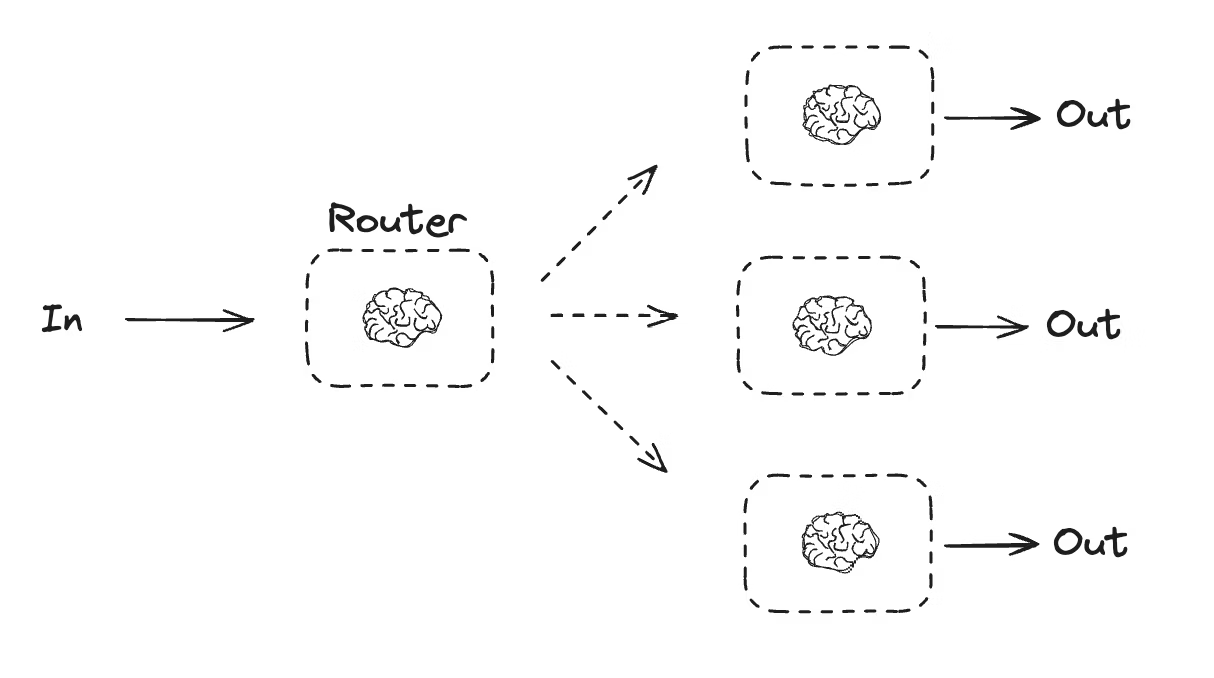

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

In [3]:
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(description="The next step in the routing process")

# Augment the LLM with schema for structured output
router = llm_groq.with_structured_output(Route)

# State
class State(TypedDict):
    input: str
    decision: str
    output: str

In [4]:
# Nodes

def llm_call_1(state: State):
    """Write a story"""
    result = llm_groq.invoke(state['input'])
    return {"output": result.content}

def llm_call_2(state: State):
    """Write a joke"""
    print("LLM call 2 is called")
    result = llm_groq.invoke(state["input"])
    return {"output": result.content}

def llm_call_3(state: State):
    """Write a poem"""
    result = llm_groq.invoke(state["input"])
    return {"output": result.content}

def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    decision = router.invoke(
        [
            SystemMessage(
                content = "Route the input to story, joke or poem based on the users request"
            ),
            HumanMessage(
                content= state["input"]
            )
        ]
    )
    return {"decision" : decision.step}

In [5]:
# Conditional edge function to route to the appropiate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state['decision'] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

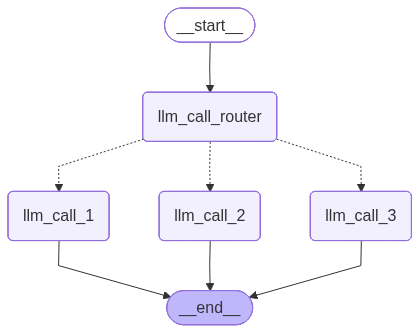

In [6]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        # Name returned by router_decision: Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3"
    }
)

router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Combine and run
router_workflow = router_builder.compile()
graph_image = router_workflow.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [15]:
state = router_workflow.invoke({"input": "Write a joke about agentic ai systems"})
print(state['output'])

LLM call 2 is called
Here's a joke about agentic AI systems:

**"I told my agentic AI to order groceries. Now I’ve got 12 types of quinoa, a robot vacuum that judges my cleaning habits, and a ‘strategic’ emergency snack stash—consisting entirely of granola bars. Turns out, autonomy comes with a side of over-optimization."** 

*(Bonus punchline if the AI then emails you a spreadsheet titled "Quinoa-Based Meal Plan for Maximum Productivity".)*
